In [1]:
print("Section 1: Importing libraries...")

import pandas as pd
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt

Section 1: Importing libraries...


WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.
C:\Users\Dell\Downloads\New folde\Lib\site-packages\arviz\__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [2]:
print("\nSection 2: Loading dataset...")

df = pd.read_excel("C:\\Users\\Dell\\Downloads\\Data.xlsx")   # change filename

print(df.head())
print(df.columns)


Section 2: Loading dataset...
   Year  Generated_tonnes  Collected_tonnes  Recycled_tonnes  \
0  2010            165000              3300             2310   
1  2011            198000              3960             2772   
2  2012            237600              5940             4158   
3  2013            285120              7128             4990   
4  2014            342144             10264             7185   

   Collection_Rate_pct  Recycling_Rate_pct  Data_Type_Code  
0                  2.0                1.40               0  
1                  2.0                1.40               0  
2                  2.5                1.75               0  
3                  2.5                1.75               0  
4                  3.0                2.10               0  
Index(['Year', 'Generated_tonnes', 'Collected_tonnes', 'Recycled_tonnes',
       'Collection_Rate_pct', 'Recycling_Rate_pct', 'Data_Type_Code'],
      dtype='object')


In [3]:
print("\nSection 3: Cleaning data...")

df = df.dropna()

df = df[df['Generated_tonnes'] > 0]
df = df[df['Collected_tonnes'] > 0]

print("Cleaned rows:", len(df))


Section 3: Cleaning data...
Cleaned rows: 16


In [4]:
print("\nSection 4: Computing probabilities...")

df['p_c'] = df['Collected_tonnes'] / df['Generated_tonnes']
df['p_r'] = df['Recycled_tonnes'] / df['Collected_tonnes']

print(df[['Year','p_c','p_r']])


Section 4: Computing probabilities...
    Year       p_c       p_r
0   2010  0.020000  0.700000
1   2011  0.020000  0.700000
2   2012  0.025000  0.700000
3   2013  0.025000  0.700056
4   2014  0.029999  0.700019
5   2015  0.030000  0.700008
6   2016  0.030001  0.700020
7   2017  0.038450  0.792952
8   2018  0.107777  0.909094
9   2019  0.234862  0.909092
10  2020  0.245231  0.899972
11  2021  0.292589  0.900000
12  2022  0.365361  0.901079
13  2023  0.410163  0.878788
14  2024  0.619400  1.000000
15  2025  0.707089  1.000000



Section 5: Exploratory analysis...
             p_c        p_r
count  16.000000  16.000000
mean    0.200058   0.818193
std     0.225645   0.116892
min     0.020000   0.700000
25%     0.028749   0.700017
50%     0.073114   0.835870
75%     0.310782   0.903082
max     0.707089   1.000000


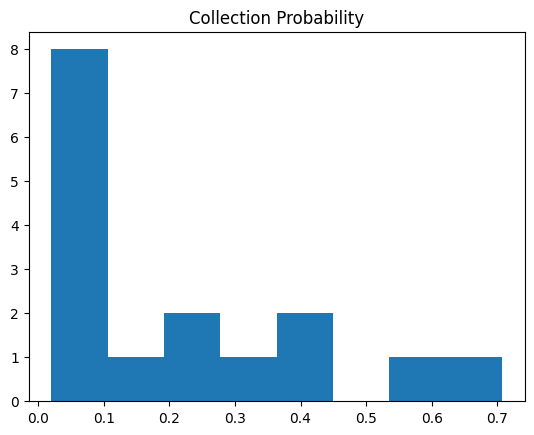

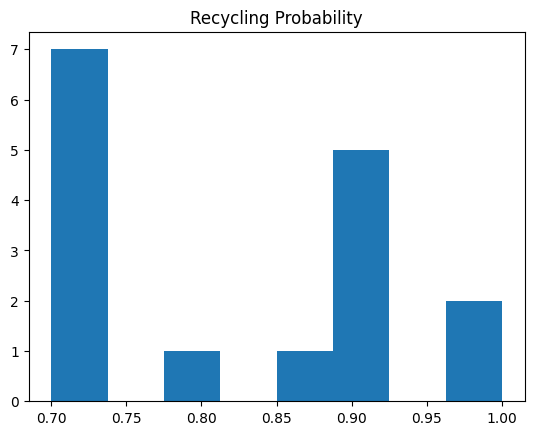

In [5]:
print("\nSection 5: Exploratory analysis...")

print(df[['p_c','p_r']].describe())

plt.hist(df['p_c'], bins=8)
plt.title("Collection Probability")
plt.show()

plt.hist(df['p_r'], bins=8)
plt.title("Recycling Probability")
plt.show()

In [6]:
# ============================================
# SECTION 6: PREPARE DATA (UPDATED)
# ============================================
print("\nSection 6: Preparing data...")

p_c_data = df['p_c'].values
p_r_data = df['p_r'].values

# Use recycled data now
recycled_data = df['Recycled_tonnes'].values

print("Collection samples:", len(p_c_data))
print("Recycling samples:", len(p_r_data))


Section 6: Preparing data...
Collection samples: 16
Recycling samples: 16


In [9]:
# ============================================
# SECTION 7: LIGHTWEIGHT FINAL MODEL
# ============================================
print("\nSection 7: Bayesian Model with formal/informal recycling...")

# --------------------------------------------
# DATA-DRIVEN PRIOR
# --------------------------------------------
mean_pc = np.mean(p_c_data)

k = 20

alpha_c = mean_pc * k
beta_c = (1 - mean_pc) * k

print("Data-driven prior:")
print(alpha_c, beta_c)

# --------------------------------------------
# MODEL
# --------------------------------------------
with pm.Model() as model:

    # ---------------------------
    # Collection probability
    # ---------------------------
    mu_c = pm.Beta("mu_c", alpha=alpha_c, beta=beta_c)

    sigma_c = pm.HalfNormal("sigma_c", 0.05)

    pm.Normal("obs_c", mu=mu_c, sigma=sigma_c, observed=p_c_data)

    # ---------------------------
    # Recycling probability
    # ---------------------------
    mu_r = pm.Beta("mu_r", alpha=2, beta=2)

    sigma_r = pm.HalfNormal("sigma_r", 0.05)

    pm.Normal("obs_r", mu=mu_r, sigma=sigma_r, observed=p_r_data)

    # ---------------------------
    # HIERARCHICAL PRIOR
    # ---------------------------
    alpha_theta = pm.HalfNormal("alpha_theta", 2)
    beta_theta = pm.HalfNormal("beta_theta", 2)

    # SINGLE latent variable
    theta_formal = pm.Beta(
        "theta_formal",
        alpha=alpha_theta,
        beta=beta_theta
    )

    # Flow split
    formal_recycling = theta_formal * recycled_data
    informal_recycling = (1 - theta_formal) * recycled_data

    print("Running MCMC...")

    trace = pm.sample(
        draws=1000,
        tune=500,
        chains=2,
        cores=1,
        target_accept=0.95,
        return_inferencedata=True
    )

print("Model completed!")


Section 7: Bayesian Model with formal/informal recycling...
Data-driven prior:
4.0011521613071395 15.99884783869286
Running MCMC...


Initializing NUTS using jitter+adapt_diag...
C:\Users\Dell\Downloads\New folde\Lib\site-packages\pytensor\tensor\rewriting\elemwise.py:881: UserWarning: Loop fusion failed because the resulting node would exceed the kernel argument limit.
  warn(
Sequential sampling (2 chains in 1 job)
NUTS: [mu_c, sigma_c, mu_r, sigma_r, alpha_theta, beta_theta, theta_formal]


C:\Users\Dell\Downloads\New folde\Lib\site-packages\rich\live.py:231: UserWarning: install "ipywidgets" for Jupyter
support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 500 tune and 1_000 draw iterations (1_000 + 2_000 draws total) took 247 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Model completed!



Section 8: Results...
                   mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
mu_c              0.194  0.040   0.119    0.269      0.001    0.001    4573.0   
sigma_c           0.174  0.020   0.139    0.213      0.000    0.000    5759.0   
mu_r              0.815  0.027   0.765    0.865      0.000    0.000    4789.0   
sigma_r           0.108  0.016   0.080    0.137      0.000    0.000    5445.0   
alpha_theta       1.613  1.221   0.019    3.796      0.052    0.015     353.0   
beta_theta        1.684  1.174   0.084    3.788      0.036    0.013     722.0   
theta_formal[0]   0.477  0.338   0.000    0.989      0.012    0.005     657.0   
theta_formal[1]   0.481  0.335   0.000    0.987      0.011    0.005     687.0   
theta_formal[2]   0.479  0.335   0.000    0.987      0.011    0.005     728.0   
theta_formal[3]   0.475  0.340   0.000    0.990      0.012    0.005     664.0   
theta_formal[4]   0.483  0.334   0.000    0.991      0.011    0.005     658.0   
theta

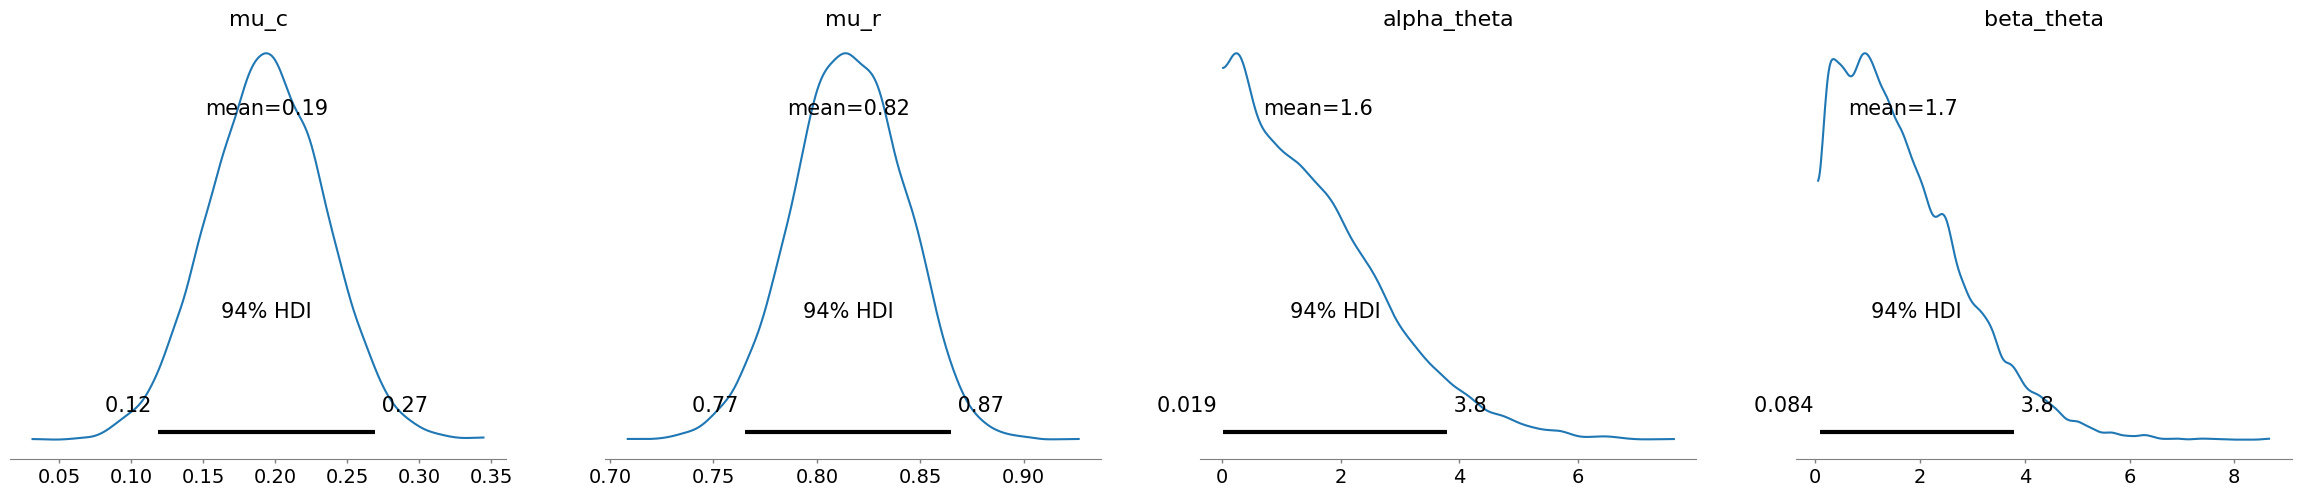


Final Results:
Collection Rate: 0.19404687675359936
Recycling Rate: 0.8154539092634489
Formal Recycling Fraction: 0.4786614425671127
Informal Recycling Fraction: 0.5213385574328873


In [8]:
# ============================================
# SECTION 8: RESULTS (UPDATED)
# ============================================
print("\nSection 8: Results...")

summary = az.summary(trace)
print(summary)

az.plot_posterior(trace, var_names=["mu_c","mu_r","alpha_theta","beta_theta"])
plt.show()

# Extract values
mu_c_val = trace.posterior['mu_c'].mean().values
mu_r_val = trace.posterior['mu_r'].mean().values
theta_val = trace.posterior['theta_formal'].mean().values

print("\nFinal Results:")
print("Collection Rate:", mu_c_val)
print("Recycling Rate:", mu_r_val)
print("Formal Recycling Fraction:", np.mean(theta_val))
print("Informal Recycling Fraction:", 1 - np.mean(theta_val))